In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saranya1207","key":"4a6ff64ca2a73d1c62f8be5b006e03ff"}'}

In [ ]:
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification

Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
tom-and-jerry-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o tom-and-jerry-image-classification.zip -d tom_jerry_data

Streaming output truncated to the last 5000 lines.
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2793.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2794.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2795.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2796.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2797.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2798.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2799.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2800.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2801.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2802.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2803.jpg  
  inflating: tom_jerry_data/tom_and_jerry/tom_and_jerry/jerry/frame2804.jpg  
  inflating: 

In [ ]:
import os
os.listdir("tom_jerry_data")

['tom_and_jerry', 'ground_truth.csv', 'challenges.csv']

In [ ]:
os.listdir("tom_jerry_data/tom_and_jerry")

['tom_and_jerry']

In [ ]:
DATA_DIR = "tom_jerry_data/tom_and_jerry/tom_and_jerry"

In [ ]:
import os
os.listdir(DATA_DIR)

['tom', 'jerry', 'tom_jerry_1', 'tom_jerry_0']

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(100, 100),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42,
    class_names=["tom", "jerry"]
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(100, 100),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42,
    class_names=["tom", "jerry"]
)

Found 3170 files belonging to 2 classes.
Using 2536 files for training.
Found 3170 files belonging to 2 classes.
Using 634 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['tom', 'jerry']


In [ ]:
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.6725 - loss: 0.6392 - val_accuracy: 0.8076 - val_loss: 0.4552
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 468ms/step - accuracy: 0.7989 - loss: 0.4262 - val_accuracy: 0.8565 - val_loss: 0.3376
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 474ms/step - accuracy: 0.8869 - loss: 0.2913 - val_accuracy: 0.8659 - val_loss: 0.3009
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 472ms/step - accuracy: 0.9075 - loss: 0.2346 - val_accuracy: 0.9117 - val_loss: 0.2419
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 470ms/step - accuracy: 0.9410 - loss: 0.1520 - val_accuracy: 0.9117 - val_loss: 0.2525
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 468ms/step - accuracy: 0.9628 - loss: 0.1040 - val_accuracy: 0.9117 - val_loss: 0.2401
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 480ms/step - accuracy: 0.9717 - loss: 0.0806 - val_accuracy: 0.9196 - val_loss: 0.2246
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 448ms/step - accuracy: 0.9843 - loss: 0.0516 - val_accu

In [ ]:
model.evaluate(val_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9280 - loss: 0.2852


[0.2775639295578003, 0.9227129220962524]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Actual: tom
Predicted: tom


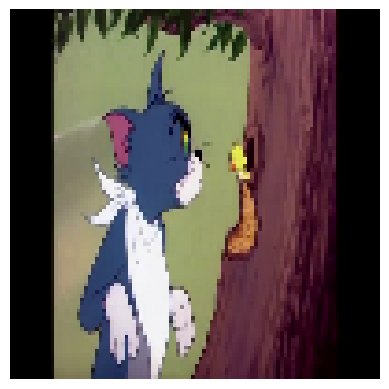

In [ ]:
import matplotlib.pyplot as plt

for images, labels in val_ds.take(1):
    img = images[0]
    true_label = labels[0].numpy()

    pred = model.predict(img.numpy().reshape(1,100,100,3))
    predicted = "jerry" if pred[0][0] > 0.5 else "tom"

    plt.imshow(img.numpy().astype("float"))
    plt.axis("off")

    print("Actual:", class_names[true_label])
    print("Predicted:", predicted)